# Calculating the Energy Response Function $R_i(E_{\nu})$

$ E_e^{\inf} = E_\nu - \Delta - \frac{E_{\nu}^{\rm cm}}{m_p}\,(E_e^{\rm cm}+p_e^{\rm cm}) $

$E_e^{\sup} = E_\nu - \Delta - \frac{E_{\nu}^{\rm cm}}{m_p}\,(E_e^{\rm cm}-p_e^{\rm cm})$

In [1]:
import numpy as np

def Ee_endpoints(E_nu, m_p, m_n, m_e):
    E_nu = np.asarray(E_nu, dtype=float)

    s = m_p**2 + 2.0*m_p*E_nu
    sqrt_s = np.sqrt(s)

    delta = (m_n**2 - m_p**2 - m_e**2) / (2.0*m_p)

    Ecm_nu = (s - m_p**2) / (2.0*sqrt_s)
    Ecm_e  = (s - m_n**2 + m_e**2) / (2.0*sqrt_s)

    lam = (s - (m_n - m_e)**2) * (s - (m_n + m_e)**2)
    lam = np.maximum(lam, 0.0)
    pcm_e = np.sqrt(lam) / (2.0*sqrt_s)

    Ee_inferior = E_nu - delta - (Ecm_nu/m_p) * (Ecm_e + pcm_e)
    Ee_superior = E_nu - delta - (Ecm_nu/m_p) * (Ecm_e - pcm_e)
    
    return Ee_inferior, Ee_superior

$E^{inf}_{Pr} = E^{inf}_e + m_e$

$E^{sup}_{Pr} = E^{sup}_e + m_e$

In [2]:
def Epr_endpoints(E_nu, m_p, m_n, m_e):
    Ee_inf, Ee_sup = Ee_endpoints(E_nu, m_p, m_n, m_e)
    Epr_inf = Ee_inf + m_e
    Epr_sup = Ee_sup + m_e
    
    return Epr_inf, Epr_sup

from src.readDayaBay import read_total_flux
DYB_PATH = "data/DYB_unfolded_spectra_tot_U235_Pu239.txt"

df_total = read_total_flux(DYB_PATH, "Total")

Phi0 = df_total["Flux"]
E_high = df_total["E_high"]
E_low = df_total["E_low"]
E_center = df_total["E_center"].to_numpy()

kg_to_MeV = 5.61e29
m_p = 1.6726219e-27 * kg_to_MeV
m_n = 1.6749275e-27 * kg_to_MeV
m_e = 9.1093837e-31 * kg_to_MeV

E_center

array([1.925, 2.175, 2.425, 2.675, 2.925, 3.175, 3.425, 3.675, 3.925,
       4.175, 4.425, 4.675, 4.925, 5.175, 5.425, 5.675, 5.925, 6.175,
       6.425, 6.675, 6.925, 7.175, 7.425, 7.675, 8.65 ])

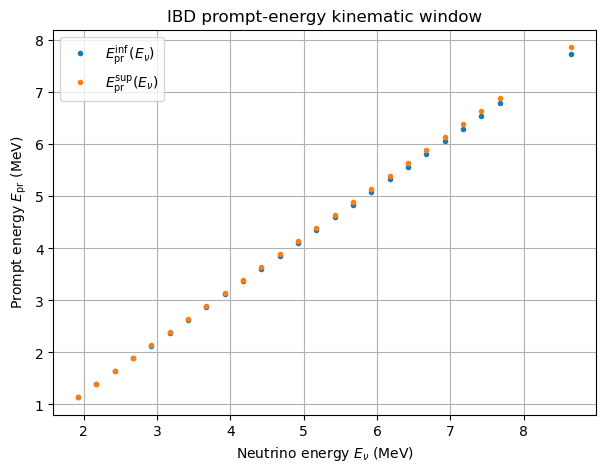

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Epr_inf, Epr_sup = Epr_endpoints(E_center, m_p, m_n, m_e)

plt.figure(figsize=(7,5))
plt.plot(E_center, Epr_inf, '.', label=r"$E_{\rm pr}^{\inf}(E_\nu)$")
plt.plot(E_center, Epr_sup, '.', label=r"$E_{\rm pr}^{\sup}(E_\nu)$")
plt.xlabel(r"Neutrino energy $E_\nu$ (MeV)")
plt.ylabel(r"Prompt energy $E_{\rm pr}$ (MeV)")
plt.legend()
plt.title("IBD prompt-energy kinematic window")
plt.grid(True)
plt.show()

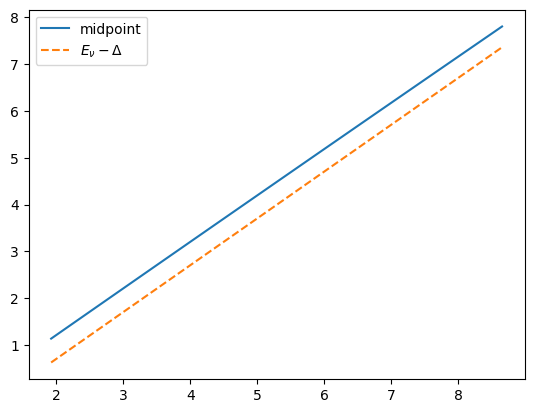

In [4]:
Epr_mid = 0.5*(Epr_inf + Epr_sup)
plt.plot(E_center, Epr_mid, label="midpoint")
plt.plot(E_center, E_center - (m_n-m_p), "--", label=r"$E_\nu-\Delta$")
plt.legend()

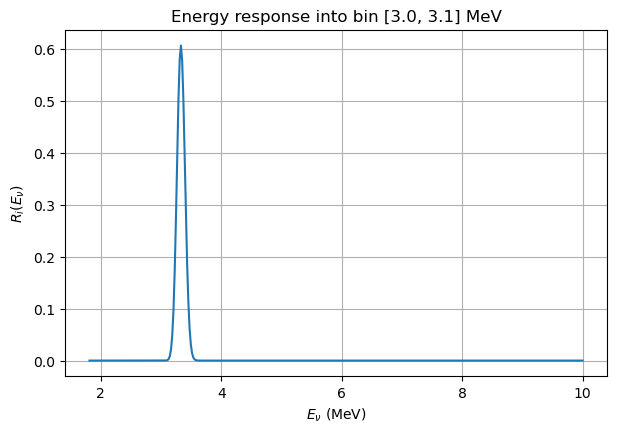

Sum over bins (min/mean/max): 0.9939884977475855 0.9999591022970455 1.0000000000030567


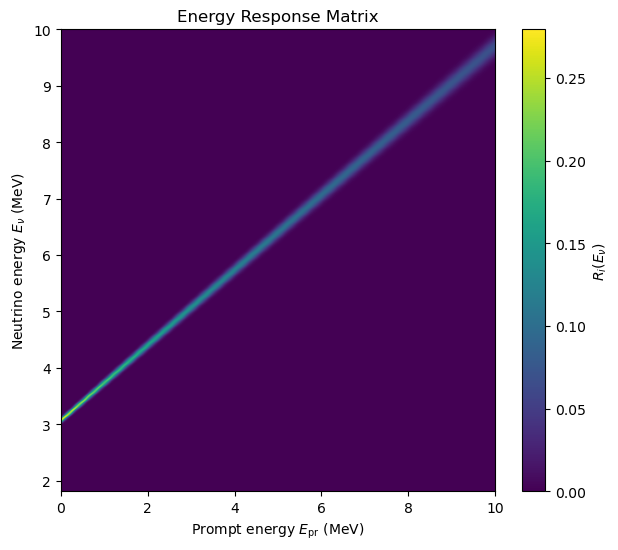

In [5]:

import numpy as np
import matplotlib.pyplot as plt

from src.energyResponse import R_i, response_matrix

# neutrino grid
E_nu = np.linspace(1.81, 10.0, 400)

# one prompt bin
Ei_lo, Ei_hi = 3.0, 3.1

W = R_i(E_nu, Ei_lo, Ei_hi)

plt.figure(figsize=(7,4.5))
plt.plot(E_nu, W)
plt.xlabel(r"$E_\nu$ (MeV)")
plt.ylabel(r"$R_i(E_\nu)$")
plt.title(rf"Energy response into bin [{Ei_lo}, {Ei_hi}] MeV")
plt.grid(True)
plt.show()

# full response matrix
Epr_edges = np.linspace(0.0, 10.0, 401)
Wmat = response_matrix(E_nu, Epr_edges)

sums = Wmat.sum(axis=0)
print("Sum over bins (min/mean/max):", sums.min(), sums.mean(), sums.max())
plt.figure(figsize=(7,6))

im = plt.imshow(
    Wmat,
    origin="lower",
    aspect="auto",
    extent=[Epr_edges[0], Epr_edges[-1], E_nu[0], E_nu[-1]]
)

plt.colorbar(im, label=r"$R_i(E_\nu)$")
plt.xlabel(r"Prompt energy $E_{\rm pr}$ (MeV)")
plt.ylabel(r"Neutrino energy $E_\nu$ (MeV)")
plt.title("Energy Response Matrix")

plt.show()